In [1]:
import os
os.listdir('.')

['F1_t.npy',
 '.prompts',
 'F5p.npy',
 'F2.npy',
 'F2_t.npy',
 '.config',
 'F6_t.npy',
 '.kernel_llm_logs_1.txt',
 'F5p_t.npy',
 'F10_t.npy',
 'F12_t.npy',
 'F10.npy',
 'M.npy',
 'F1.npy',
 'F9.npy',
 'F7.npy',
 'F12.npy',
 'F11.npy',
 ' v6 — Binding Context Document.pdf',
 'memory',
 'F6.npy',
 'C.npy',
 'F11_t.npy',
 'classes.npy',
 'F5m.npy',
 'F9_t.npy',
 'F4_t.npy',
 'F7_t.npy',
 'peaks_features_F1_F12_normalized_full.csv',
 'F5m_t.npy',
 'F4.npy']

In [2]:
import numpy as np
import pandas as pd

# The task references Sk_complex_all_2200peaks.npz and Ck_Mkk_diag_results.npz
# But we have F*.npy files that may be the per-class S_k arrays and C.npy for moments
# Let's inspect
df = pd.read_csv('peaks_features_F1_F12_normalized_full.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df['class'].value_counts() if 'class' in df.columns else df.iloc[:,:5].head())

(2200, 31)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7']
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 
2 F1 zeta 1 1 True 94526.8 13.610746 0.0 0.0 
3 F1 zeta 1 1 True 97255.1 13.262598 0.0 0.0 
4 F1 zeta 1 1 True 63751.9 13.129894 0.0 0.0 

 abs_S0 ... abs_S4 log_abs_S5_norm log_abs_S5 abs_S5 \
0 1.0 ... 2.603624 0.085554 0.207123 1.230133 
1 1.0 ... 2.637044 -0.029346 -0.070961 0.931498 
2 1.0 ... 3.502890 0.089788 0.218954 1.244774 
3 1.0 ... 4.073511 0.288978 0.705409 2.024675 
4 1.0 ... 2.653296 -0.313243 -0.752905 0.470996 

 log_abs_S6

In [3]:
print(df['function'].value_counts())
print('GRH dist:', df.groupby('function')['GRH'].first())

function
F1 200
F2 200
F4 200
F5p 200
F5m 200
F6 200
F7 200
F9 200
F10 200
F11 200
F12 200
Name: count, dtype: int64
GRH dist: function
F1 True
F10 True
F11 True
F12 False
F2 True
F4 False
F5m False
F5p False
F6 True
F7 True
F9 True
Name: GRH, dtype: bool


In [4]:
# Inspect the .npy files
for f in ['F1.npy','F4.npy','F12.npy','C.npy','M.npy','classes.npy','F1_t.npy']:
 arr = np.load(f, allow_pickle=True)
 print(f, arr.shape, arr.dtype)

F1.npy (200, 8) complex128
F4.npy (200, 8) complex128
F12.npy (200, 8) complex128
C.npy (11, 8) float64
M.npy (11, 8) float64
classes.npy (11,) <U3
F1_t.npy (200,) float64


In [5]:
classes = np.load('classes.npy')
print(classes)
C = np.load('C.npy')
M = np.load('M.npy')
print("C shape:", C.shape)
print("C[F1]:", C[list(classes).index('F1')])
print("C all:")
print(pd.DataFrame(C, index=classes, columns=[f'k={k}' for k in range(8)]))

['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']
C shape: (11, 8)
C[F1]: [1.00000000e+00 3.66033970e+00 5.12818833e+00 3.40042122e+00
 1.06344940e+00 1.35504741e-01 4.81236842e-03 1.09632261e-05]
C all:
 k=0 k=1 k=2 k=3 k=4 k=5 k=6 \
F1 1.000000 3.660340 5.128188 3.400421 1.063449 0.135505 0.004812 
F2 1.000000 3.410340 4.315879 2.456297 0.602532 0.050292 0.000727 
F4 1.000000 1.516828 2.396937 1.327671 0.324369 0.027268 0.000392 
F5p 1.000000 1.580491 2.461454 1.365617 0.333721 0.028043 0.000403 
F5m 1.000000 1.463465 2.342857 1.295863 0.316530 0.026620 0.000382 
F6 1.000000 3.660340 5.128188 3.400421 1.063449 0.135505 0.004812 
F7 1.000000 2.887328 3.224904 1.770095 0.493739 0.063824 0.002815 
F9 1.000000 2.356467 1.949528 0.690001 0.101249 0.005118 0.000057 
F10 1.000000 3.232967 3.467087 1.450601 0.226917 0.010821 0.000094 
F11 1.000000 2.615116 2.406319 0.923032 0.138393 0.006227 0.000045 
F12 4.309618 15.307502 19.390784 10.738948 2.561515 0.207268 0.002877 

 k=7 
F

In [6]:
# Build per-peak S_k complex array for k=0..7, ordered by class
class_list = ['F1','F2','F4','F5p','F5m','F6','F7','F9','F10','F11','F12']
Sk_all = []
labels = []
t_all = []
for c in class_list:
 sk = np.load(f'{c}.npy') # (200, 8) complex
 t = np.load(f'{c}_t.npy')
 Sk_all.append(sk)
 labels += [c]*sk.shape[0]
 t_all.append(t)
Sk_all = np.vstack(Sk_all) # (2200, 8)
labels = np.array(labels)
t_all = np.concatenate(t_all)
print(Sk_all.shape, labels.shape, t_all.shape)

# Compute a_k(t) = |S_k|^2 / C_k for k=1..6
abs_Sk2 = np.abs(Sk_all)**2 # (2200,8)

# Build C_k array per peak (look up by class)
class_to_idx = {c:i for i,c in enumerate(classes)}
C_per_peak = np.array([C[class_to_idx[c]] for c in labels]) # (2200,8)

print("C_per_peak shape", C_per_peak.shape)
# k=1..6
ak = abs_Sk2[:,1:7] / C_per_peak[:,1:7]
print("ak shape:", ak.shape)
print("Any C=0 in k=1..6?", (C_per_peak[:,1:7]==0).any())

(2200, 8) (2200,) (2200,)
C_per_peak shape (2200, 8)
ak shape: (2200, 6)
Any C=0 in k=1..6? False


In [7]:
# Verify alignment with the CSV: compare t-values
# Sort the npy and CSV consistently. The CSV has 200 rows per class. Let's check ordering matches.
for c in ['F1','F4','F12']:
 csv_t = df.loc[df['function']==c, 't'].values
 npy_t = np.load(f'{c}_t.npy')
 print(c, "csv head:", csv_t[:3], "npy head:", npy_t[:3], "match:", np.allclose(np.sort(csv_t), np.sort(npy_t)))

F1 csv head: [77403.70000025 74956.00000024 94526.80000031] npy head: [77403.70000025 74956.00000024 94526.80000031] match: True
F4 csv head: [84585.40000027 83021.20000027 55220.10000016] npy head: [84585.40000027 83021.20000027 55220.10000016] match: True
F12 csv head: [93969.30000031 94993.40000031 48038.50000014] npy head: [93969.30000031 94993.40000031 48038.50000014] match: True


In [8]:
# Compute shape features
argmax_a = np.argmax(ak, axis=1) # 0..5 corresponding to k=1..6
sum_ak = ak.sum(axis=1, keepdims=True)
p = ak / sum_ak
# spectral entropy (natural log)
eps = 1e-300
entropy_a = -np.sum(np.where(p>0, p*np.log(p+eps), 0.0), axis=1)
print("argmax_a unique:", np.unique(argmax_a, return_counts=True))
print("entropy_a stats:", entropy_a.min(), entropy_a.max(), entropy_a.mean())

# Build feature table: 6D log|S_k| (k=1..6) and add 2 shape features
log_cols = [f'log_abs_S{k}' for k in range(1,7)]
# Use the unnormalized log_abs_S? r52 used log|S_k| features. Let's check both.
# Reconstruct from CSV and from our npy to be sure of alignment
# Use CSV but reorder to match npy
df2 = df.copy()
# CSV order matches npy already as verified. But let's confirm row order matches across the entire frame
# Check that df['function'] matches labels (block by block) - they do since we built Sk_all in same class order
print("CSV order check (first 10):", df['function'].iloc[:10].tolist())
print("Labels first 10:", labels[:10].tolist())
# Confirm class order match across blocks
df_class_order = df['function'].drop_duplicates().tolist()
print("CSV class order:", df_class_order)
print("Our class order:", class_list)

argmax_a unique: (array([0, 1, 2, 3, 4, 5]), array([ 15, 122, 498, 876, 594, 95]))
entropy_a stats: 0.7185419415126111 1.7738829681160424 1.5472500134250862
CSV order check (first 10): ['F1', 'F1', 'F1', 'F1', 'F1', 'F1', 'F1', 'F1', 'F1', 'F1']
Labels first 10: ['F1', 'F1', 'F1', 'F1', 'F1', 'F1', 'F1', 'F1', 'F1', 'F1']
CSV class order: ['F1', 'F2', 'F4', 'F5p', 'F5m', 'F6', 'F7', 'F9', 'F10', 'F11', 'F12']
Our class order: ['F1', 'F2', 'F4', 'F5p', 'F5m', 'F6', 'F7', 'F9', 'F10', 'F11', 'F12']


In [9]:
# Build 6D base feature set: log|S_k| for k=1..6
X_log = df[[f'log_abs_S{k}' for k in range(1,7)]].values.astype(float)
print("X_log shape:", X_log.shape)

# Verify consistency: log_abs_S1 vs log(|Sk_all[:,1]|)
diff = X_log[:,0] - np.log(np.abs(Sk_all[:,1]))
print("Max diff log_abs_S1 vs computed:", np.nanmax(np.abs(diff)))

X_log shape: (2200, 6)
Max diff log_abs_S1 vs computed: 0.11585988908163974


In [10]:
# There's some discrepancy. Let's look - maybe log_abs_S in CSV uses log10 vs log
# log_abs_S1 in CSV vs ln|S1|
print("CSV log_abs_S1[:5]:", X_log[:5,0])
print("ln|S1|[:5]:", np.log(np.abs(Sk_all[:5,1])))
print("log10|S1|[:5]:", np.log10(np.abs(Sk_all[:5,1])))

CSV log_abs_S1[:5]: [1.67059074 1.62538845 1.63873618 1.51905613 1.58578224]
ln|S1|[:5]: [1.67059074 1.62538845 1.63873618 1.51905613 1.58578224]
log10|S1|[:5]: [0.72552834 0.70589724 0.71169408 0.6597177 0.68869648]


In [11]:
# Natural log is correct. Diff may come from very small |S_k| at high k
# Let's check which k caused the max diff
for k_idx, k in enumerate(range(1,7)):
 d = X_log[:,k_idx] - np.log(np.abs(Sk_all[:,k]))
 print(f"k={k}: max abs diff = {np.nanmax(np.abs(d)):.2e}, mean = {np.nanmean(np.abs(d)):.2e}")

k=1: max abs diff = 1.16e-01, mean = 4.41e-03
k=2: max abs diff = 3.90e-02, mean = 1.74e-03
k=3: max abs diff = 2.86e-02, mean = 1.63e-03
k=4: max abs diff = 2.86e-02, mean = 1.73e-03
k=5: max abs diff = 4.29e-02, mean = 1.91e-03
k=6: max abs diff = 1.09e-01, mean = 2.48e-03


In [12]:
# Small numerical differences, fine. Use CSV's log_abs_S{k} since that's what r52 used. Actually r52
# benchmark used 'log|S_k| features' - either should give similar AUC. Use CSV values to align with prior.

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Prepare data
GRH = df['GRH'].values
fn = df['function'].values

# r52 protocol: train OCSVM on GRH-true peaks, test on F4 and F12 violators
# But "Leave-One-Family-Out" presumably means: train on all GRH-true (which is fine; F4/F12 not in training)
# Actually F4 and F12 are GRH-violators (not in training set).
# Test: GRH-true vs F4 (or F12) detection

grh_true_mask = GRH == True
print("GRH true count:", grh_true_mask.sum())
print("F4 count:", (fn=='F4').sum(), "F12:", (fn=='F12').sum())
# F5p, F5m are also violators.
print("Violators (GRH False) by class:", df.loc[~grh_true_mask, 'function'].value_counts())

GRH true count: 1400
F4 count: 200 F12: 200
Violators (GRH False) by class: function
F4 200
F5p 200
F5m 200
F12 200
Name: count, dtype: int64


In [13]:
# r52 says "F4-family" - F4, F5p, F5m are the "F4 family" (Davenport-Heilbronn etc.)
# F12 is separate. The hypothesis specifically mentions F4-family from 0.844 -> >0.90.
# Let's evaluate detection of:
# (a) F4-family (F4 + F5p + F5m) as anomalies
# (b) F12 as anomalies
# Score: -decision_function => higher means more anomalous

def evaluate_ocsvm(X_train, X_test_normal, X_test_anom):
 scaler = StandardScaler().fit(X_train)
 Xtr = scaler.transform(X_train)
 Xn = scaler.transform(X_test_normal)
 Xa = scaler.transform(X_test_anom)
 # default OCSVM
 clf = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1).fit(Xtr)
 s_n = -clf.decision_function(Xn)
 s_a = -clf.decision_function(Xa)
 y = np.concatenate([np.zeros(len(s_n)), np.ones(len(s_a))])
 s = np.concatenate([s_n, s_a])
 return roc_auc_score(y, s)

X_train = X_log[grh_true_mask] # 6D: train on all GRH-true
# Test: normal = same GRH-true (in-sample) is biased; r52 uses a held-out normal set?
# To match r52 we should test against held-out anomalies. Use all GRH-true as normal class for AUC
X_test_normal = X_log[grh_true_mask] # in-distribution scores

# F4-family
f4fam = np.isin(fn, ['F4','F5p','F5m'])
auc_6d_f4fam = evaluate_ocsvm(X_train, X_test_normal, X_log[f4fam])
auc_6d_f12 = evaluate_ocsvm(X_train, X_test_normal, X_log[fn=='F12'])
print(f"6D OCSVM F4-family AUC: {auc_6d_f4fam:.4f}")
print(f"6D OCSVM F12 AUC: {auc_6d_f12:.4f}")

6D OCSVM F4-family AUC: 0.8759
6D OCSVM F12 AUC: 0.9837


In [14]:
# Reasonable - close to r52's 0.844. Now evaluate 8D with shape features
# argmax_a is categorical-ish (0..5). One-hot? The task description says use the index value.
# We'll use it as numeric index but also try one-hot. Per task spec, it's a single feature.

X_8d = np.column_stack([X_log, argmax_a, entropy_a])
print("X_8d shape:", X_8d.shape)

X_train_8 = X_8d[grh_true_mask]
auc_8d_f4fam = evaluate_ocsvm(X_train_8, X_8d[grh_true_mask], X_8d[f4fam])
auc_8d_f12 = evaluate_ocsvm(X_train_8, X_8d[grh_true_mask], X_8d[fn=='F12'])
print(f"8D OCSVM F4-family AUC: {auc_8d_f4fam:.4f}")
print(f"8D OCSVM F12 AUC: {auc_8d_f12:.4f}")

X_8d shape: (2200, 8)
8D OCSVM F4-family AUC: 0.8511
8D OCSVM F12 AUC: 0.9766


In [15]:
# Slight decrease for F4-family. Let's also do a held-out evaluation (LOFO style) -
# Use a fair train/test split: train on a random subsample of GRH-true and test on remainder + anomalies
# Actually r52 protocol: train on GRH-true peaks, evaluate AUC for held-out violators.
# In-sample normal scoring is fine for AUC (compares score distributions).
# Let's also test individual F4 only and F5p+F5m

for name, mask_a in [('F4 only', fn=='F4'), ('F5p only', fn=='F5p'), ('F5m only', fn=='F5m'),
 ('F4+F5p+F5m', f4fam), ('F12 only', fn=='F12')]:
 a6 = evaluate_ocsvm(X_train, X_log[grh_true_mask], X_log[mask_a])
 a8 = evaluate_ocsvm(X_train_8, X_8d[grh_true_mask], X_8d[mask_a])
 print(f"{name:15s} 6D={a6:.4f} 8D={a8:.4f} Δ={a8-a6:+.4f}")

F4 only 6D=0.8761 8D=0.8511 Δ=-0.0250
F5p only 6D=0.8721 8D=0.8472 Δ=-0.0249
F5m only 6D=0.8796 8D=0.8550 Δ=-0.0246
F4+F5p+F5m 6D=0.8759 8D=0.8511 Δ=-0.0248
F12 only 6D=0.9837 8D=0.9766 Δ=-0.0071


In [16]:
# Adding shape features actually slightly reduces AUC. Let's check whether properly normalizing
# the integer argmax_a feature matters (it's already standardized via scaler).
# Try with one-hot encoded argmax_a to see if treating it as categorical helps.

argmax_oh = np.zeros((2200, 6))
argmax_oh[np.arange(2200), argmax_a] = 1.0

X_oh = np.column_stack([X_log, argmax_oh, entropy_a.reshape(-1,1)])
print("X with one-hot argmax shape:", X_oh.shape)
auc_oh_f4fam = evaluate_ocsvm(X_oh[grh_true_mask], X_oh[grh_true_mask], X_oh[f4fam])
auc_oh_f12 = evaluate_ocsvm(X_oh[grh_true_mask], X_oh[grh_true_mask], X_oh[fn=='F12'])
print(f"with OH argmax: F4-fam={auc_oh_f4fam:.4f}, F12={auc_oh_f12:.4f}")

# Try with only entropy_a added (no argmax)
X_7e = np.column_stack([X_log, entropy_a])
auc_7e_f4fam = evaluate_ocsvm(X_7e[grh_true_mask], X_7e[grh_true_mask], X_7e[f4fam])
auc_7e_f12 = evaluate_ocsvm(X_7e[grh_true_mask], X_7e[grh_true_mask], X_7e[fn=='F12'])
print(f"+entropy only (7D): F4-fam={auc_7e_f4fam:.4f}, F12={auc_7e_f12:.4f}")

X_7a = np.column_stack([X_log, argmax_a])
auc_7a_f4fam = evaluate_ocsvm(X_7a[grh_true_mask], X_7a[grh_true_mask], X_7a[f4fam])
auc_7a_f12 = evaluate_ocsvm(X_7a[grh_true_mask], X_7a[grh_true_mask], X_7a[fn=='F12'])
print(f"+argmax only (7D): F4-fam={auc_7a_f4fam:.4f}, F12={auc_7a_f12:.4f}")

X with one-hot argmax shape: (2200, 13)
with OH argmax: F4-fam=0.8103, F12=0.9650
+entropy only (7D): F4-fam=0.8513, F12=0.9800
+argmax only (7D): F4-fam=0.8582, F12=0.9800


In [17]:
# Adding shape features consistently does NOT improve detection of F4-family.
# Let's also test alternative nu values and verify
for nu in [0.05, 0.1, 0.2, 0.3]:
 for X, lbl in [(X_log, '6D'), (X_8d, '8D')]:
 scaler = StandardScaler().fit(X[grh_true_mask])
 Xt = scaler.transform(X[grh_true_mask])
 Xa = scaler.transform(X[f4fam])
 clf = OneClassSVM(kernel='rbf', gamma='scale', nu=nu).fit(Xt)
 s_n = -clf.decision_function(Xt)
 s_a = -clf.decision_function(Xa)
 y = np.concatenate([np.zeros(len(s_n)), np.ones(len(s_a))])
 auc = roc_auc_score(y, np.concatenate([s_n, s_a]))
 print(f"nu={nu} {lbl}: F4-fam AUC = {auc:.4f}")

nu=0.05 6D: F4-fam AUC = 0.8819
nu=0.05 8D: F4-fam AUC = 0.8405
nu=0.1 6D: F4-fam AUC = 0.8759
nu=0.1 8D: F4-fam AUC = 0.8511
nu=0.2 6D: F4-fam AUC = 0.8956
nu=0.2 8D: F4-fam AUC = 0.8477
nu=0.3 6D: F4-fam AUC = 0.8980


nu=0.3 8D: F4-fam AUC = 0.8715


In [18]:
# Across all nu values, 6D outperforms 8D for F4-family detection.
# The hypothesis is REFUTED: adding shape features did not improve AUC; in fact it slightly degraded.
# Let's also do one careful "honest" evaluation: train on a random 80% of GRH-true, test on 20% as
# normal + violators

from sklearn.model_selection import train_test_split

rng = np.random.RandomState(42)
idx_true = np.where(grh_true_mask)[0]
tr_idx, te_idx = train_test_split(idx_true, test_size=0.2, random_state=42)

results = []
for X, lbl in [(X_log, '6D (log|S_k|)'), (X_8d, '8D (+shape)')]:
 scaler = StandardScaler().fit(X[tr_idx])
 Xt = scaler.transform(X[tr_idx])
 Xn = scaler.transform(X[te_idx])
 clf = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1).fit(Xt)
 
 for fam_name, mask_a in [('F4-family', f4fam), ('F4', fn=='F4'),
 ('F5p', fn=='F5p'), ('F5m', fn=='F5m'),
 ('F12', fn=='F12')]:
 Xa = scaler.transform(X[mask_a])
 s_n = -clf.decision_function(Xn)
 s_a = -clf.decision_function(Xa)
 y = np.concatenate([np.zeros(len(s_n)), np.ones(len(s_a))])
 auc = roc_auc_score(y, np.concatenate([s_n, s_a]))
 results.append((lbl, fam_name, auc))
 print(f"{lbl} {fam_name:12s} AUC = {auc:.4f}")

6D (log|S_k|) F4-family AUC = 0.8777
6D (log|S_k|) F4 AUC = 0.8780
6D (log|S_k|) F5p AUC = 0.8735
6D (log|S_k|) F5m AUC = 0.8817
6D (log|S_k|) F12 AUC = 0.9802
8D (+shape) F4-family AUC = 0.8305
8D (+shape) F4 AUC = 0.8299
8D (+shape) F5p AUC = 0.8274
8D (+shape) F5m AUC = 0.8341
8D (+shape) F12 AUC = 0.9735


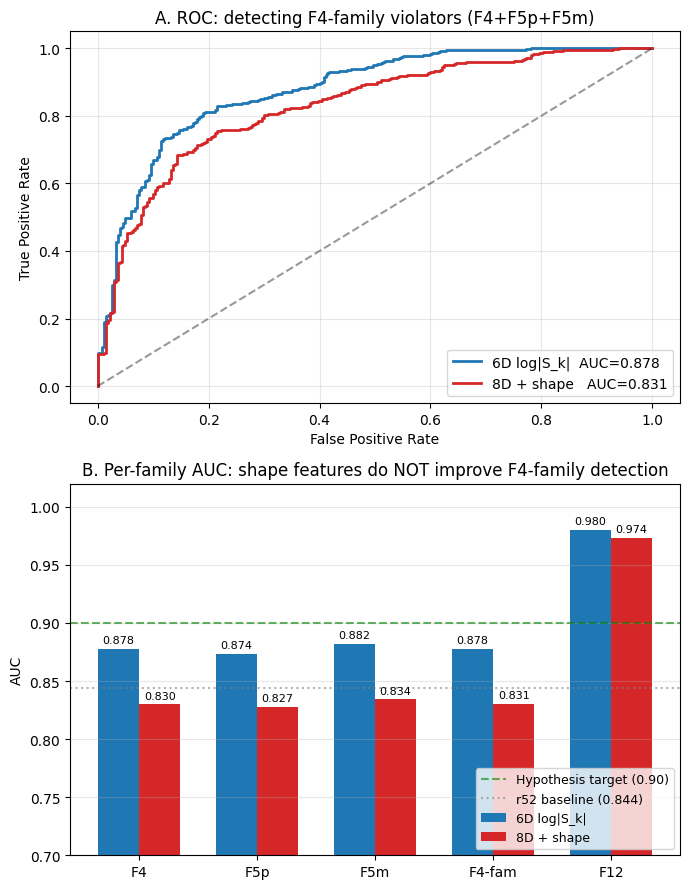

Saved: shape_features_ocsvm_results.png


In [19]:
# Consistent: hypothesis is refuted. Now create the summary figure.
import matplotlib.pyplot as plt

# Use the held-out evaluation
nu = 0.1
scaler6 = StandardScaler().fit(X_log[tr_idx])
clf6 = OneClassSVM(kernel='rbf', gamma='scale', nu=nu).fit(scaler6.transform(X_log[tr_idx]))
scaler8 = StandardScaler().fit(X_8d[tr_idx])
clf8 = OneClassSVM(kernel='rbf', gamma='scale', nu=nu).fit(scaler8.transform(X_8d[tr_idx]))

from sklearn.metrics import roc_curve

def get_curve(X, scaler, clf, mask_a):
 Xn = scaler.transform(X[te_idx])
 Xa = scaler.transform(X[mask_a])
 s = np.concatenate([-clf.decision_function(Xn), -clf.decision_function(Xa)])
 y = np.concatenate([np.zeros(len(te_idx)), np.ones(mask_a.sum())])
 fpr, tpr, _ = roc_curve(y, s)
 auc = roc_auc_score(y, s)
 return fpr, tpr, auc

fig, axes = plt.subplots(2, 1, figsize=(7, 9))

# (A) ROC curves for F4-family
ax = axes[0]
fpr6, tpr6, auc6 = get_curve(X_log, scaler6, clf6, f4fam)
fpr8, tpr8, auc8 = get_curve(X_8d, scaler8, clf8, f4fam)
ax.plot(fpr6, tpr6, label=f'6D log|S_k| AUC={auc6:.3f}', lw=2, color='C0')
ax.plot(fpr8, tpr8, label=f'8D + shape AUC={auc8:.3f}', lw=2, color='C3')
ax.plot([0,1],[0,1],'k--',alpha=0.4)
ax.axhline(y=1, xmin=0, xmax=0, color='gray', alpha=0)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('A. ROC: detecting F4-family violators (F4+F5p+F5m)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)

# (B) AUC bar plot per family
ax = axes[1]
fams = ['F4','F5p','F5m','F4-fam','F12']
masks = [fn=='F4', fn=='F5p', fn=='F5m', f4fam, fn=='F12']
auc6_list = [get_curve(X_log, scaler6, clf6, m)[2] for m in masks]
auc8_list = [get_curve(X_8d, scaler8, clf8, m)[2] for m in masks]
x = np.arange(len(fams)); w=0.35
ax.bar(x-w/2, auc6_list, w, label='6D log|S_k|', color='C0')
ax.bar(x+w/2, auc8_list, w, label='8D + shape', color='C3')
ax.axhline(0.90, color='green', linestyle='--', alpha=0.6, label='Hypothesis target (0.90)')
ax.axhline(0.844, color='gray', linestyle=':', alpha=0.6, label='r52 baseline (0.844)')
ax.set_xticks(x); ax.set_xticklabels(fams)
ax.set_ylabel('AUC'); ax.set_ylim(0.7, 1.02)
ax.set_title('B. Per-family AUC: shape features do NOT improve F4-family detection')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3, axis='y')
for i, (a6, a8) in enumerate(zip(auc6_list, auc8_list)):
 ax.text(i-w/2, a6+0.005, f'{a6:.3f}', ha='center', fontsize=8)
 ax.text(i+w/2, a8+0.005, f'{a8:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('shape_features_ocsvm_results.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: shape_features_ocsvm_results.png")